In [1]:
from pathlib import Path
import yaml

import torch
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision import transforms

import matplotlib.pyplot as plt

from tqdm import tqdm
from kornia.losses import FocalLoss, DiceLoss

import timm

# Moduli progetto
from models.model import ChimeraSeg
from models.decoder import Decoder, DecoderWithFAM
from training.train import Trainer
from training.losses import ClassDescriptorLoss
from training.metrics import MeanIoU
from data.streethazards import StreetHazards, STREET_HAZARDS_CLASSES, get_classes_as_dict
from data.multi_epochs_dataloader import MultiEpochsDataLoader
from utils.misc import get_device, fix_random, print_summary

from utils.visualize import COLORS, color

# Configurazioni di ambiente
%load_ext autoreload
%autoreload 2

/home/aarcara/miniconda3/envs/ml4cv/lib/python3.11/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.4' (you have '2.0.3'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()



Premessa: come il mio precedente notebook, link al notebook, sono interessato ad avere delle reti efficienti che mi permettano di poter trainare liberamente e fare diverse prove anche su un dispositivo mac con `mps`.

Guardando i diversi paper che ottenevano alti score nel benchmark SegmentMeIfYouCan, i migliori come mIoU utilizzano Mask classification e di conseguenza Mask2Former con l'aggiunta di un modulo o di tecniche per aggiungere anche il rilevamento di anomalie. Tra tutti ho preferito implementare il paper `Open Semantic Segmentation with Class Similarity` che ottiene un mIoU competitivo, rimanendo al contempo veloce a differenza degli approcci con Mask2Former più lenti di natura, e con un rilevamento di anomalie decisamente migliore. Successivamente, data la recente uscita del paper `Open Panoptic Segmentation`, sempre degli stessi autori, che oltre ad aggiungere la Panoptic Segmentation, risolve alcuni problemi del precedente approccio.

In [2]:
config_path = "./config.yaml"

with open(config_path, "r") as file:
    config = yaml.safe_load(file)

fix_random(config['seed'])
device = get_device()

🚀 CUDA device is available!


In [ ]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
imgH = config['training']['img_height']
imgW = config['training']['img_width']

data_transforms = {
    "train": A.Compose([
        A.RandomCrop(height=imgH, width=imgW),
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.CoarseDropout(max_holes=8, max_height=imgH//8, max_width=imgW//8, min_holes=1, min_height=imgH//16, min_width=imgW//16, p=0.5),
        A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
        ToTensorV2(),
    ]),
    "val": A.Compose([
        A.Resize(height=imgH, width=imgW),
        A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
        ToTensorV2(),
    ])
}

denorm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)

/tmp/ipykernel_330149/3309906447.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=imgH//8, max_width=imgW//8, min_holes=1, min_height=imgH//16, min_width=imgW//16, p=0.5),


In [4]:
train_root = Path.home() / config['paths']['train_path']

train_data = StreetHazards(
    train_root,
    "training",
    transforms=data_transforms["train"]
)

val_data = StreetHazards(
    train_root,
    "validation",
    transforms=data_transforms["val"]
)

num_classes = len(STREET_HAZARDS_CLASSES)
class_dict = get_classes_as_dict()

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of classes: {num_classes}")

Number of training samples: 5125
Number of validation samples: 1031
Number of classes: 14


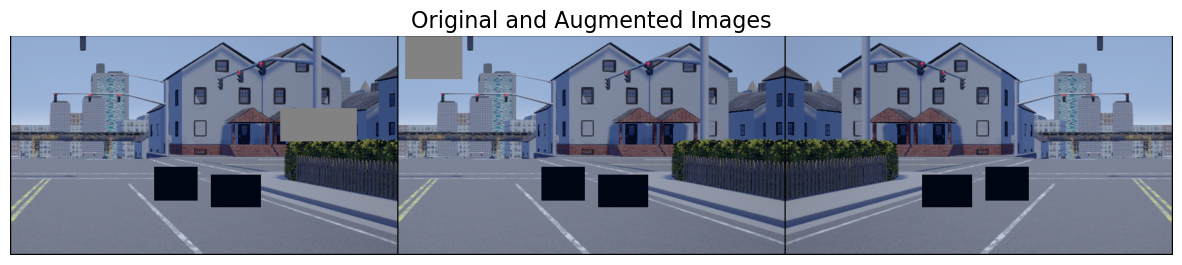

In [5]:
from torchvision.utils import make_grid

def visualize_augmentations(dataset, num_samples=4):
    img, _ = dataset[0]

    imgs = []

    for _ in range(num_samples - 1):
        img_np = img.permute(1, 2, 0).numpy()
        augmented = data_transforms['train'](image=img_np)['image']
        denormalized = denorm(augmented)
        imgs.append(denormalized)

    img_grid = make_grid(imgs, nrow=4, normalize=True)

    plt.figure(figsize=(15,15))
    plt.imshow(img_grid.permute(1, 2, 0).numpy())
    plt.title("Original and Augmented Images", fontsize=16)
    plt.axis('off')
    plt.show()

visualize_augmentations(train_data)

In [6]:
import os
NUM_WORKERS = os.cpu_count() - 1

train_loader = MultiEpochsDataLoader(
    train_data,
    batch_size=config['training']['batch_size'],
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=3
)

val_loader = MultiEpochsDataLoader(
    val_data,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 321
Number of validation batches: 65


In [7]:
class_weights = train_data.get_class_weights().to(device)
class_weights = class_weights[:-1]
num_classes = num_classes - 1
print(len(class_weights))
print(num_classes)

tensor([5125., 4519., 3488., 3554., 1500., 5022., 5077., 5122., 4165., 4673.,
        2239., 4054., 4182.], device='cuda:0')
13


COMMENTI:

* la wce converge meglio rispetto alla focal loss, ma risulta meno stabile e ogni tanto sul validation diverge decisamente
* best score right now on validation it's 0.55 mIoU,
* attualmente il mio modello fa fatica sulle parti lontane dell'immagine dove il modello non riesce a capire esattamente cosa c'è nell'immagine e sugli oggetti molto piccoli
* il modello non è preciso ai bordi, come affrontare il problema?
* aspp fa qualcosa?



In [ ]:
do_train = True 

model_name = 'resnet18d'
encoder = timm.create_model(model_name, features_only=True, pretrained=True)
#decoder = Decoder([128, 256, 512], (360, 640), num_classes, atrous_rates=(6, 12, 18))
decoder = DecoderWithFAM([64, 64, 128, 256, 512], num_classes, input_size=(imgH, imgW), d=64) # -1 because the last class is for anomalies and we don't need here
model = ChimeraSeg(encoder, decoder)
#model(torch.rand((4, 3, 640, 360)))
print_summary(model, (64, 3, 360, 640))

criterions = [(0.8, nn.CrossEntropyLoss(weight=class_weights, label_smoothing=config['training']['ls'])), (0.2, ClassDescriptorLoss(num_classes, 64))]
#criterions = [(20, FocalLoss(weight=class_weights, alpha=0.5, gamma=2, reduction='mean')), (1, DiceLoss())]

trainer = Trainer(
    config, 
    model, 
    device, 
    train_loader, 
    criterions,
    val_loader,
    class_dict=class_dict, 
    metrics=[MeanIoU(num_classes)],
)

if do_train:
    trainer.train(f"i:360x640/e:{model_name}/d:4fam64/l:wce")
else:
    pass

Value(False)


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/resnet18d.ra2_in1k)
INFO:timm.models._hub:[timm/resnet18d.ra2_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Layer (type:depth-idx)                        Output Shape              Param #
ChimeraSeg                                    [64, 64, 360, 640]        --
├─FeatureListNet: 1-1                         [64, 64, 180, 320]        --
│    └─Sequential: 2-1                        [64, 64, 180, 320]        --
│    │    └─Conv2d: 3-1                       [64, 32, 180, 320]        864
│    │    └─BatchNorm2d: 3-2                  [64, 32, 180, 320]        64
│    │    └─ReLU: 3-3                         [64, 32, 180, 320]        --
│    │    └─Conv2d: 3-4                       [64, 32, 180, 320]        9,216
│    │    └─BatchNorm2d: 3-5                  [64, 32, 180, 320]        64
│    │    └─ReLU: 3-6                         [64, 32, 180, 320]        --
│    │    └─Conv2d: 3-7                       [64, 64, 180, 320]        18,432
│    └─BatchNorm2d: 2-2                       [64, 64, 180, 320]        128
│    └─ReLU: 2-3                              [64, 64, 180, 320]        --
│    └─MaxP

wandb: Currently logged in as: alessioarcara (IPCV_ASS2). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1 Batches:   0%|          | 0/321 [00:00<?, ?it/s]

/opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/native/cuda/NLLLoss2d.cu:106: nll_loss2d_forward_kernel: block: [13,0,0], thread: [224,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/native/cuda/NLLLoss2d.cu:106: nll_loss2d_forward_kernel: block: [13,0,0], thread: [225,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/native/cuda/NLLLoss2d.cu:106: nll_loss2d_forward_kernel: block: [13,0,0], thread: [226,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/native/cuda/NLLLoss2d.cu:106: nll_loss2d_forward_kernel: block: [13,0,0], thread: [227,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/native/cuda/NLLLoss2d.cu:106: nll_loss2d_forward_kernel: block: [13,0,0], thread: [864,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [21]:
import wandb 
wandb.finish()

In [13]:
torch.cuda.empty_cache()

nel training devo vedere due metriche mIoU, mAP, F1 score? e 